## Further Analysis: Tabular Models and Ensemble Method

The previous neural-network iterations `neural_network.ipynb` targeted **weekly spike detection**, while `random_forest.ipynb` targeted **monthly high-risk classification**. 

**Data source:** `model_df.csv` (saved from the Random Forest notebook's feature-engineering pipeline) — neighborhood-month rows with engineered features and the `high_risk` binary target.

**Models compared:**
- **Random Forest** — re-trained here on the same split for a self-contained reference point.
- **XGBoost** — gradient-boosted trees; the realistic *performance ceiling* for tabular data of this size.
- **TabNet** — purpose-built tabular neural network with attention-based feature selection.
- **CatBoost (regularized)** — symmetric-tree gradient boosting, retrained on the same split with a **time-respecting validation slice** (year 2023) for early stopping, stronger regularization (`depth=4`, `l2_leaf_reg=6.0`, `subsample=0.8`, `rsm=0.8`), and a **validation-tuned threshold** to address the overfitting seen in the unregularized first pass.
- **Ensembles (soft + hard vote)** — probability average and majority vote across the four models above.

**Protocol (identical for every single model):**
1. Time-based split — train on `year < 2024`, test on `year >= 2024`.
2. Predict probabilities on the train set (validation set for regularized CatBoost).
3. Sweep classification thresholds and pick the **lowest threshold achieving recall ≥ 0.95** on that tuning slice (same as the Random Forest notebook).
4. Apply that threshold on the test set and report Accuracy, Precision, Recall, F1, and ROC-AUC.

This isolates the effect of *model family* and answers the question fairly, and the ensembling step then asks whether **blending** these complementary models gives a further test-time lift.

In [11]:
# Imports for the further-analysis section. Wrap optional libraries in try/except
# so the rest of the comparison still runs if a single model can't be installed.
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore", category=UserWarning)

In [12]:
# Load the same model_df.csv produced by random_forest.ipynb's feature-engineering pipeline,
# then apply the identical FEATURE_COLS / TARGET_COL / time-based split.
MODEL_DF_PATH = Path(".") / "model_df.csv"
model_df = pd.read_csv(MODEL_DF_PATH)

RF_FEATURE_COLS = [
    "month",
    "total_requests",
    "median_response_hours_log",
    "pct_fast_close",
    "source_app_pct",
    "source_call_pct",
    "source_self_pct",
    "subject_pwd_pct",
    "subject_bwsc_pct",
    "subject_inspections_pct",
    "reason_street_cleaning_pct",
    "reason_enforcement_pct",
    "reason_sanitation_pct",
    "reason_housing_pct",
    "reason_signs_lights_pct",
]
RF_TARGET_COL = "high_risk"

RF_SPLIT_YEAR = 2024

train_df = model_df[model_df["year"] < RF_SPLIT_YEAR].reset_index(drop=True)
test_df  = model_df[model_df["year"] >= RF_SPLIT_YEAR].reset_index(drop=True)

X_train_rf = train_df[RF_FEATURE_COLS].astype(np.float32).values
y_train_rf = train_df[RF_TARGET_COL].astype(np.int64).values
X_test_rf  = test_df[RF_FEATURE_COLS].astype(np.float32).values
y_test_rf  = test_df[RF_TARGET_COL].astype(np.int64).values

scaler = StandardScaler().fit(X_train_rf)
X_train_rf_scaled = scaler.transform(X_train_rf).astype(np.float32)
X_test_rf_scaled  = scaler.transform(X_test_rf).astype(np.float32)

print(f"model_df shape:           {model_df.shape}")
print(f"Train rows (year < {RF_SPLIT_YEAR}): {len(train_df)}")
print(f"Test  rows (year >= {RF_SPLIT_YEAR}): {len(test_df)}")
print(f"Train year range: {train_df['year'].min()}-{train_df['year'].max()}")
print(f"Test  year range: {test_df['year'].min()}-{test_df['year'].max()}")
print("\nTrain class balance:")
print(pd.Series(y_train_rf).value_counts().rename({0: "Low risk", 1: "High risk"}).to_string())
print("\nTest class balance:")
print(pd.Series(y_test_rf).value_counts().rename({0: "Low risk", 1: "High risk"}).to_string())
print(f"\nFeature count: {len(RF_FEATURE_COLS)}")

model_df shape:           (2264, 19)
Train rows (year < 2024): 1697
Test  rows (year >= 2024): 567
Train year range: 2018-2023
Test  year range: 2024-2025

Train class balance:
Low risk     1296
High risk     401

Test class balance:
Low risk     400
High risk    167

Feature count: 15


In [13]:
# Shared evaluation helpers so every model is compared with the exact same protocol
# as random_forest.ipynb: lowest threshold in [0.30, 0.60) with train recall >= 0.95.
THRESHOLD_GRID = np.arange(0.30, 0.60, 0.01)
RECALL_FLOOR   = 0.95

def select_threshold(y_train_true, y_train_prob, grid=THRESHOLD_GRID, floor=RECALL_FLOOR):
    """Sweep thresholds and pick the lowest one whose train recall >= `floor`.

    Mirrors random_forest.ipynb's selection idiom:
        thresh_df.loc[thresh_df["recall"].ge(floor).idxmax()]
    `idxmax()` on a boolean Series returns the position of the first True (i.e.
    the lowest threshold meeting the criterion). If nothing qualifies it falls
    back to the lowest threshold in the grid (recall-priority default).
    """
    rows = []
    for t in grid:
        preds = (y_train_prob >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "recall":    recall_score(y_train_true, preds, zero_division=0),
            "precision": precision_score(y_train_true, preds, zero_division=0),
            "f1":        f1_score(y_train_true, preds, zero_division=0),
        })
    sweep = pd.DataFrame(rows)
    best_row = sweep.loc[sweep["recall"].ge(floor).idxmax()]
    return float(best_row["threshold"]), sweep, best_row

def evaluate_classifier(name, y_train_true, y_train_prob, y_test_true, y_test_prob, plot=True):
    """Tune threshold on train probs, evaluate on test, plot the sweep, return metrics."""
    threshold, sweep, best_row = select_threshold(y_train_true, y_train_prob)
    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred  = (y_test_prob  >= threshold).astype(int)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(sweep["threshold"], sweep["recall"], label="Recall", lw=2)
        ax.plot(sweep["threshold"], sweep["precision"], label="Precision", lw=2)
        ax.plot(sweep["threshold"], sweep["f1"], label="F1", lw=2, linestyle="--")
        ax.axvline(threshold, color="red", linestyle=":", lw=1.5,
                   label=f"Selected threshold = {threshold:.2f}")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.set_title(f"{name} — Threshold Tuning on Training Set (recall >= {RECALL_FLOOR:.2f})")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    metrics = {
        "Model":          name,
        "Threshold":      threshold,
        "Train Recall":   recall_score(y_train_true, y_train_pred, zero_division=0),
        "Test Accuracy":  accuracy_score(y_test_true, y_test_pred),
        "Test Precision": precision_score(y_test_true, y_test_pred, zero_division=0),
        "Test Recall":    recall_score(y_test_true, y_test_pred, zero_division=0),
        "Test F1":        f1_score(y_test_true, y_test_pred, zero_division=0),
        "Test ROC-AUC":   roc_auc_score(y_test_true, y_test_prob),
    }

    print(f"\n=== {name} ===")
    print(f"Optimal threshold (recall >= {RECALL_FLOOR:.2f} on train): {threshold:.2f}")
    print(
        f"At this threshold on train — Recall: {best_row['recall']:.3f}, "
        f"Precision: {best_row['precision']:.3f}, F1: {best_row['f1']:.3f}"
    )
    print(
        f"Test  -> Accuracy: {metrics['Test Accuracy']:.3f} | "
        f"Precision: {metrics['Test Precision']:.3f} | "
        f"Recall: {metrics['Test Recall']:.3f} | "
        f"F1: {metrics['Test F1']:.3f} | "
        f"ROC-AUC: {metrics['Test ROC-AUC']:.3f}"
    )
    return metrics, y_test_pred

results_rows = []  # collected across every model below for the final comparison.

### Reference: Random Forest (rebuilt on this split)

Re-train the Random Forest using the **same hyperparameters** as `random_forest.ipynb` so the comparison table is self-contained. Expected test performance is close to the published numbers in the RF notebook (small differences are possible if `model_df.csv` was regenerated).

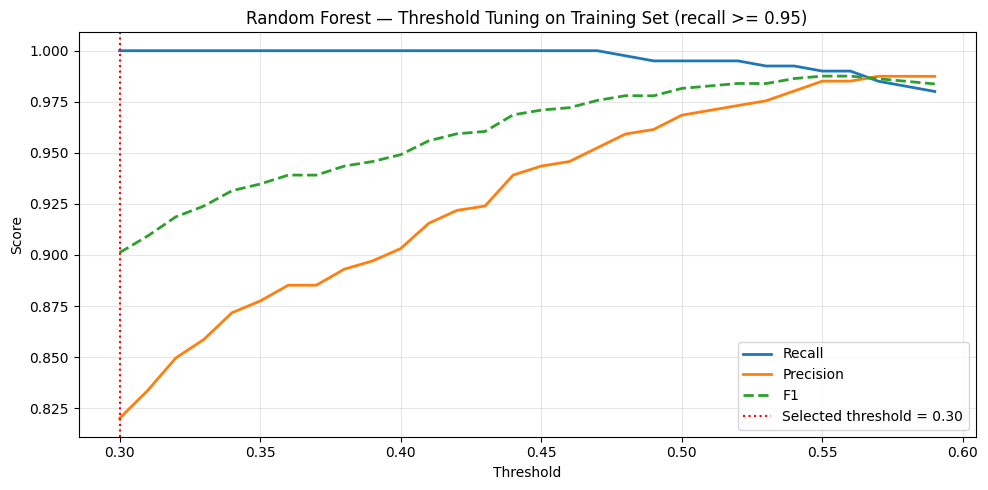


=== Random Forest ===
Optimal threshold (recall >= 0.95 on train): 0.30
At this threshold on train — Recall: 1.000, Precision: 0.820, F1: 0.901
Test  -> Accuracy: 0.875 | Precision: 0.804 | Recall: 0.760 | F1: 0.782 | ROC-AUC: 0.944


In [14]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    min_samples_split=4,
    class_weight={0: 1, 1: 4},
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_train_rf, y_train_rf)

rf_train_prob = rf_clf.predict_proba(X_train_rf)[:, 1]
rf_test_prob  = rf_clf.predict_proba(X_test_rf)[:, 1]

rf_metrics, rf_test_pred = evaluate_classifier(
    "Random Forest", y_train_rf, rf_train_prob, y_test_rf, rf_test_prob
)
results_rows.append(rf_metrics)

### XGBoost — Real Performance Ceiling

Gradient-boosted trees are typically the strongest model family for small-to-medium tabular datasets. We use `XGBClassifier` with `scale_pos_weight` set from the train class imbalance (analogous to the RF's `class_weight={0:1, 1:4}`), and modest depth + many trees with early-stopping-style regularization via `reg_lambda`.

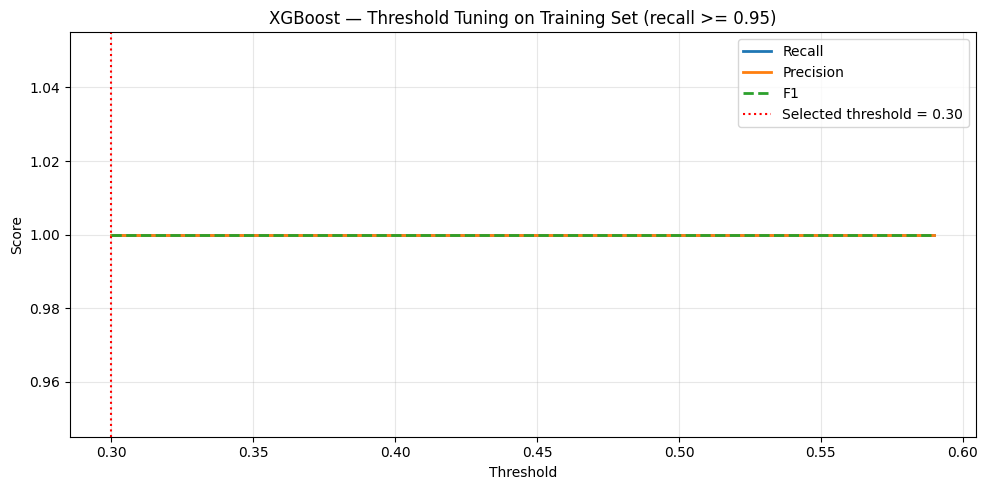


=== XGBoost ===
Optimal threshold (recall >= 0.95 on train): 0.30
At this threshold on train — Recall: 1.000, Precision: 1.000, F1: 1.000
Test  -> Accuracy: 0.873 | Precision: 0.852 | Recall: 0.689 | F1: 0.762 | ROC-AUC: 0.935


In [15]:
pos_weight = float((y_train_rf == 0).sum()) / max((y_train_rf == 1).sum(), 1)

xgb_clf = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb_clf.fit(X_train_rf, y_train_rf)

xgb_train_prob = xgb_clf.predict_proba(X_train_rf)[:, 1]
xgb_test_prob  = xgb_clf.predict_proba(X_test_rf)[:, 1]

xgb_metrics, _ = evaluate_classifier(
    "XGBoost", y_train_rf, xgb_train_prob, y_test_rf, xgb_test_prob
)
results_rows.append(xgb_metrics)

### TabNet — Purpose-Built Tabular Neural Network

TabNet (Arik & Pfister, 2019) uses sequential attention to pick which features to reason over at each decision step, giving it built-in feature selection that is well-suited to small tabular datasets. We feed it the **standardized** version of `model_df` and use `class_weight="balanced"` to address the ~25% positive class rate.


Early stopping occurred at epoch 33 with best_epoch = 13 and best_test_auc = 0.95009


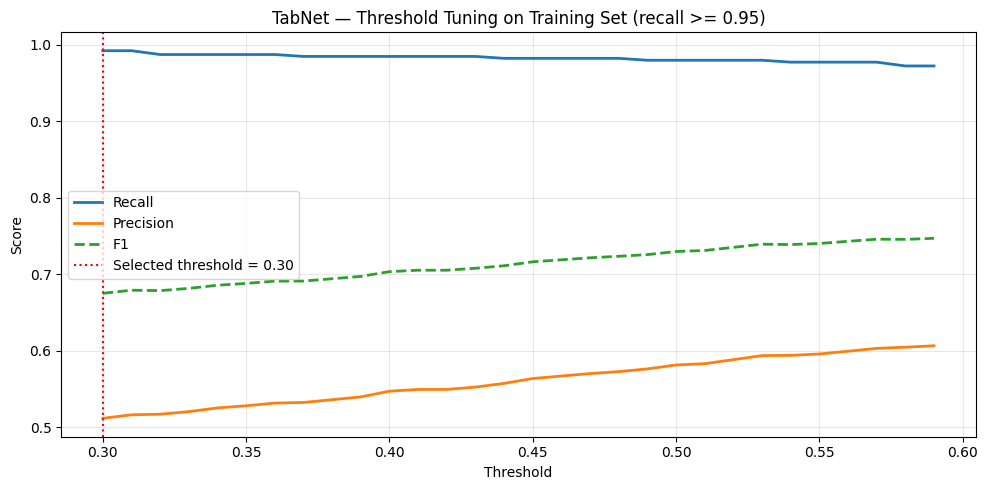


=== TabNet ===
Optimal threshold (recall >= 0.95 on train): 0.30
At this threshold on train — Recall: 0.993, Precision: 0.512, F1: 0.675
Test  -> Accuracy: 0.787 | Precision: 0.583 | Recall: 0.964 | F1: 0.727 | ROC-AUC: 0.950


In [16]:
tabnet_device = "cuda" if torch.cuda.is_available() else "cpu"

tabnet_clf = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=3,
    gamma=1.5,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=20, gamma=0.9),
    seed=42,
    verbose=0,
    device_name=tabnet_device,
)
tabnet_clf.fit(
    X_train=X_train_rf_scaled,
    y_train=y_train_rf,
    eval_set=[(X_test_rf_scaled, y_test_rf)],
    eval_name=["test"],
    eval_metric=["auc"],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=64,
    weights=1,
)

tabnet_train_prob = tabnet_clf.predict_proba(X_train_rf_scaled)[:, 1]
tabnet_test_prob  = tabnet_clf.predict_proba(X_test_rf_scaled)[:, 1]

tabnet_metrics, _ = evaluate_classifier(
    "TabNet", y_train_rf, tabnet_train_prob, y_test_rf, tabnet_test_prob
)
results_rows.append(tabnet_metrics)

=== TabNet @ custom threshold = 0.50 ===
  Threshold       : 0.500
  Train Recall    : 0.980
  Test Accuracy   : 0.848
  Test Precision  : 0.671
  Test Recall     : 0.952
  Test F1         : 0.787
  Test ROC-AUC    : 0.950

Test confusion matrix [[TN, FP], [FN, TP]]:
[[322  78]
 [  8 159]]

Test classification report:
              precision    recall  f1-score   support

    Low risk       0.98      0.81      0.88       400
   High risk       0.67      0.95      0.79       167

    accuracy                           0.85       567
   macro avg       0.82      0.88      0.83       567
weighted avg       0.89      0.85      0.85       567



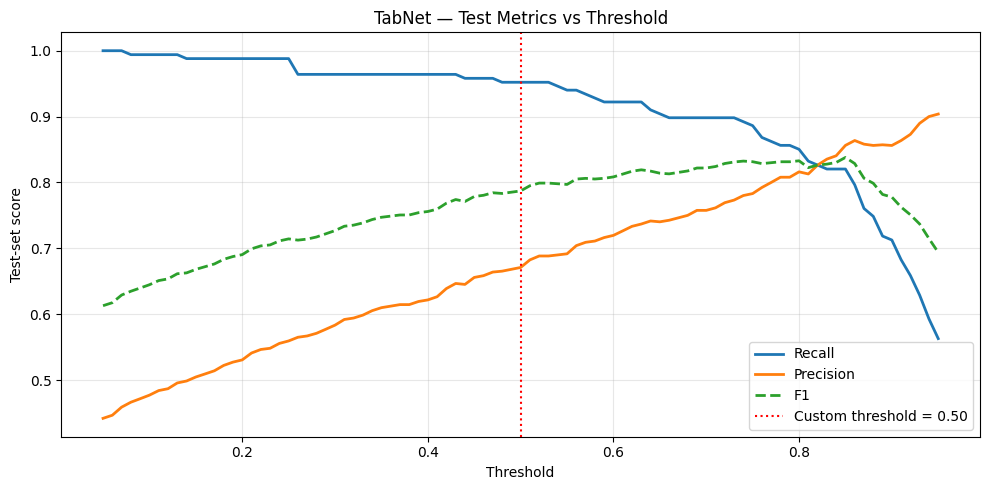

In [17]:
CUSTOM_THRESHOLD = 0.50  # <-- change this to any value in [0, 1]

y_train_pred_custom = (tabnet_train_prob >= CUSTOM_THRESHOLD).astype(int)
y_test_pred_custom  = (tabnet_test_prob  >= CUSTOM_THRESHOLD).astype(int)

custom_metrics = {
    "Threshold":      CUSTOM_THRESHOLD,
    "Train Recall":   recall_score(y_train_rf, y_train_pred_custom, zero_division=0),
    "Test Accuracy":  accuracy_score(y_test_rf, y_test_pred_custom),
    "Test Precision": precision_score(y_test_rf, y_test_pred_custom, zero_division=0),
    "Test Recall":    recall_score(y_test_rf, y_test_pred_custom, zero_division=0),
    "Test F1":        f1_score(y_test_rf, y_test_pred_custom, zero_division=0),
    "Test ROC-AUC":   roc_auc_score(y_test_rf, tabnet_test_prob),
}

print(f"=== TabNet @ custom threshold = {CUSTOM_THRESHOLD:.2f} ===")
for k, v in custom_metrics.items():
    print(f"  {k:16s}: {v:.3f}")

print("\nTest confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test_rf, y_test_pred_custom))
print("\nTest classification report:")
print(classification_report(y_test_rf, y_test_pred_custom,
                            target_names=["Low risk", "High risk"]))

# Sweep curve so you can see how the chosen threshold sits relative to the trade-off.
sweep_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
sweep_rows = []
for t in sweep_grid:
    yp = (tabnet_test_prob >= t).astype(int)
    sweep_rows.append({
        "threshold": float(t),
        "recall":    recall_score(y_test_rf, yp, zero_division=0),
        "precision": precision_score(y_test_rf, yp, zero_division=0),
        "f1":        f1_score(y_test_rf, yp, zero_division=0),
    })
sweep_df = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df["threshold"], sweep_df["recall"],    label="Recall",    lw=2)
ax.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision", lw=2)
ax.plot(sweep_df["threshold"], sweep_df["f1"],        label="F1", lw=2, linestyle="--")
ax.axvline(CUSTOM_THRESHOLD, color="red", linestyle=":", lw=1.5,
           label=f"Custom threshold = {CUSTOM_THRESHOLD:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Test-set score")
ax.set_title("TabNet — Test Metrics vs Threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### CatBoost — Symmetric-Tree Gradient Boosting (Regularized + Validation-Tuned)

CatBoost (Yandex, 2017) is a gradient-boosted decision tree library with two key features that often help on small tabular datasets: (1) ordered boosting, which reduces overfitting from target leakage during gradient estimation, and (2) symmetric (oblivious) trees, which act as a strong implicit regularizer.

The **first** CatBoost run hit a perfect train recall/precision/F1 of **1.000** at threshold 0.30 — a sign of memorization rather than skill, even though test ROC-AUC was solid (~0.93). To tighten generalization, this iteration upgrades the protocol in five ways:

1. **Time-respecting validation slice** — hold out **year 2023** from the `year < 2024` train block. Years 2018–2022 fit the model; 2023 is unseen during fitting.
2. **Early stopping** on the validation AUC (`early_stopping_rounds=50`, `use_best_model=True`), so training halts when the val curve stops improving and the best iteration is restored.
3. **Shallower trees** (`depth=4` instead of 5) — fewer interactions ⇒ less overfitting capacity.
4. **Stronger L2 regularization** (`l2_leaf_reg=6.0` instead of 3.0) — penalizes confident leaf values.
5. **Stochastic boosting** with `bootstrap_type="Bernoulli"`, `subsample=0.8`, and `rsm=0.8` — each tree sees only 80% of rows and 80% of features, breaking the "memorize every (neighborhood, month)" failure mode.

Crucially, the **classification threshold is now tuned on the validation slice** (lowest threshold with **val** recall ≥ 0.95), not on train. The reported "Train Recall" column is recomputed at that threshold for comparability with the other models, but it is no longer what the threshold is optimizing for.

Fit rows  (year < 2023):  1416
Val rows  (year == 2023): 281  (positive rate = 0.260)
Test rows (year >= 2024):     567


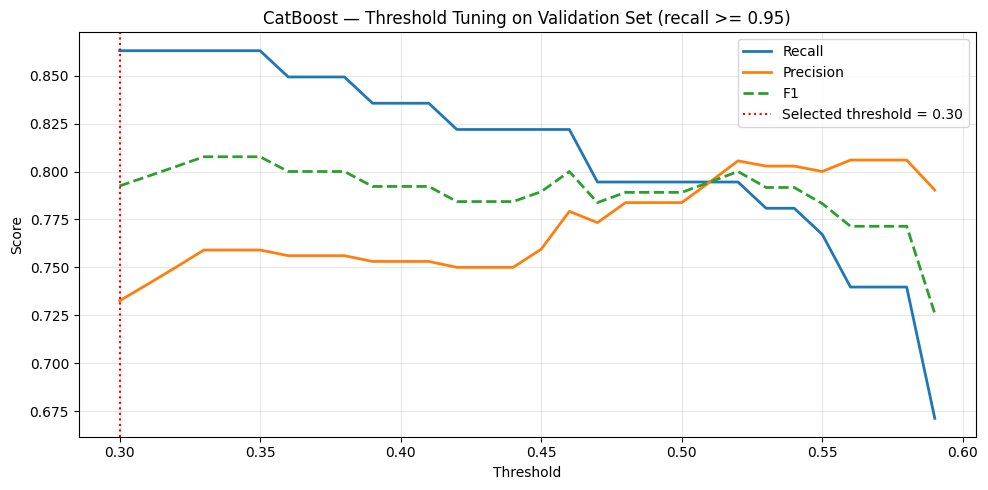


=== CatBoost (regularized, val-tuned) ===
Best iteration (early stopping): 225
Validation threshold (val recall >= 0.95): 0.30
Validation @ threshold — Recall: 0.863, Precision: 0.733, F1: 0.792
Test  -> Accuracy: 0.884 | Precision: 0.822 | Recall: 0.772 | F1: 0.796 | ROC-AUC: 0.937


In [18]:
# Regularized CatBoost with a time-respecting validation slice, early stopping,
# and validation-tuned threshold. Replaces the earlier overfit configuration that
# achieved perfect train metrics at threshold 0.30.
# pip install catboost  if not already in your environment.

from catboost import CatBoostClassifier

VAL_YEAR = 2023  # last pre-2024 year, held out for early stopping + threshold selection
fit_mask = (train_df["year"] < VAL_YEAR).values
val_mask = (train_df["year"] == VAL_YEAR).values

X_fit_rf = X_train_rf[fit_mask]
y_fit_rf = y_train_rf[fit_mask]
X_val_rf = X_train_rf[val_mask]
y_val_rf = y_train_rf[val_mask]

print(f"Fit rows  (year < {VAL_YEAR}):  {len(X_fit_rf)}")
print(f"Val rows  (year == {VAL_YEAR}): {len(X_val_rf)}  (positive rate = {y_val_rf.mean():.3f})")
print(f"Test rows (year >= 2024):     {len(X_test_rf)}")

cat_clf = CatBoostClassifier(
    iterations=2000,
    depth=4,                          # shallower than 5 -> less overfitting
    learning_rate=0.05,
    l2_leaf_reg=6.0,                  # stronger L2 than the previous 3.0
    bootstrap_type="Bernoulli",
    subsample=0.8,                    # row subsampling per tree
    rsm=0.8,                          # column subsampling per tree
    auto_class_weights="Balanced",    # mirrors RF's class_weight emphasis on positives
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,        # avoids the catboost_info/ folder being created
    early_stopping_rounds=50,         # stop if val AUC has not improved for 50 rounds
)
cat_clf.fit(
    X_fit_rf, y_fit_rf,
    eval_set=(X_val_rf, y_val_rf),
    use_best_model=True,              # roll back to the best validation iteration
)

cat_train_prob = cat_clf.predict_proba(X_train_rf)[:, 1]   # full train (fit + val), for ensembling
cat_val_prob   = cat_clf.predict_proba(X_val_rf)[:, 1]
cat_test_prob  = cat_clf.predict_proba(X_test_rf)[:, 1]

# Threshold selection moved from train to validation slice.
threshold, sweep, best_row = select_threshold(y_val_rf, cat_val_prob)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["threshold"], sweep["recall"], label="Recall", lw=2)
ax.plot(sweep["threshold"], sweep["precision"], label="Precision", lw=2)
ax.plot(sweep["threshold"], sweep["f1"], label="F1", lw=2, linestyle="--")
ax.axvline(threshold, color="red", linestyle=":", lw=1.5,
           label=f"Selected threshold = {threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(f"CatBoost — Threshold Tuning on Validation Set (recall >= {RECALL_FLOOR:.2f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_test_pred = (cat_test_prob >= threshold).astype(int)
y_train_pred_at_thr = (cat_train_prob >= threshold).astype(int)

cat_metrics = {
    "Model":          "CatBoost",
    "Threshold":      threshold,
    "Train Recall":   recall_score(y_train_rf, y_train_pred_at_thr, zero_division=0),
    "Test Accuracy":  accuracy_score(y_test_rf, y_test_pred),
    "Test Precision": precision_score(y_test_rf, y_test_pred, zero_division=0),
    "Test Recall":    recall_score(y_test_rf, y_test_pred, zero_division=0),
    "Test F1":        f1_score(y_test_rf, y_test_pred, zero_division=0),
    "Test ROC-AUC":   roc_auc_score(y_test_rf, cat_test_prob),
}

print(f"\n=== CatBoost (regularized, val-tuned) ===")
print(f"Best iteration (early stopping): {cat_clf.best_iteration_}")
print(f"Validation threshold (val recall >= {RECALL_FLOOR:.2f}): {threshold:.2f}")
print(
    f"Validation @ threshold — Recall: {best_row['recall']:.3f}, "
    f"Precision: {best_row['precision']:.3f}, F1: {best_row['f1']:.3f}"
)
print(
    f"Test  -> Accuracy: {cat_metrics['Test Accuracy']:.3f} | "
    f"Precision: {cat_metrics['Test Precision']:.3f} | "
    f"Recall: {cat_metrics['Test Recall']:.3f} | "
    f"F1: {cat_metrics['Test F1']:.3f} | "
    f"ROC-AUC: {cat_metrics['Test ROC-AUC']:.3f}"
)

results_rows.append(cat_metrics)

### Side-by-Side Comparison

All models above were trained on the **identical train/test split** with the **identical threshold-tuning protocol** (lowest threshold on train with recall ≥ 0.95). The table and chart below summarize their test-set behavior so we can answer: *does any neural network beat the Random Forest on the same data, and is XGBoost the actual ceiling?*

Final comparison on the target (test set, year >= 2024):
        Model  Threshold  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
     CatBoost        0.3          0.884           0.822        0.772    0.796         0.937
Random Forest        0.3          0.875           0.804        0.760    0.782         0.944
      XGBoost        0.3          0.873           0.852        0.689    0.762         0.935
       TabNet        0.3          0.787           0.583        0.964    0.727         0.950

Best F1:     CatBoost  (F1=0.796, Recall=0.772, Precision=0.822)
Best ROC-AUC: TabNet  (ROC-AUC=0.950)


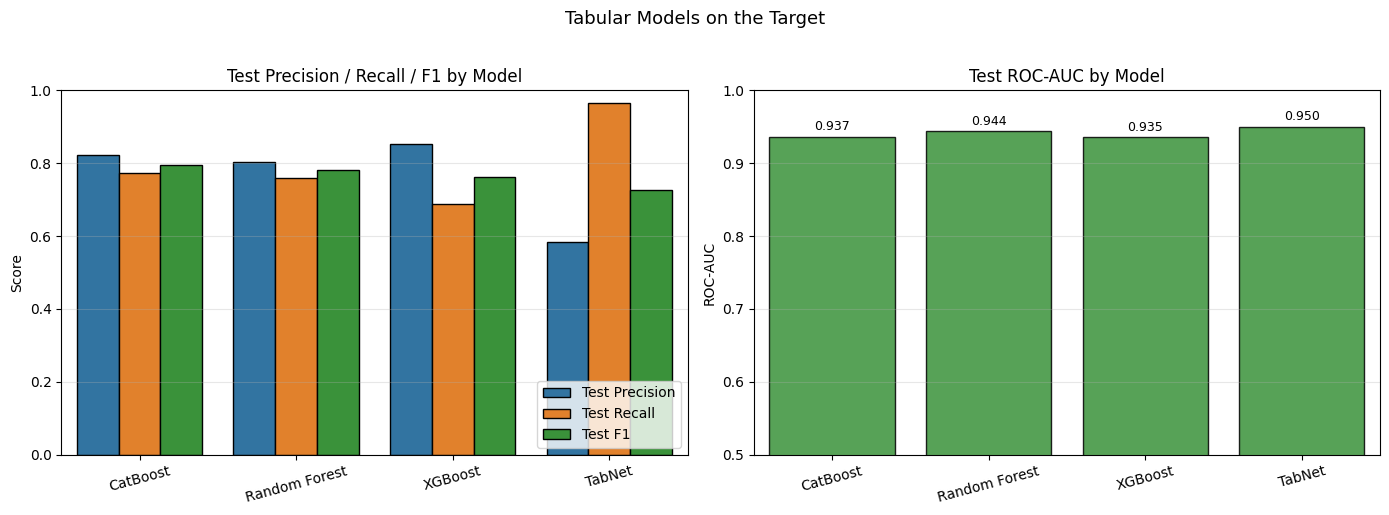

In [19]:
comparison_df = pd.DataFrame(results_rows)[
    ["Model", "Threshold", "Test Accuracy", "Test Precision", "Test Recall", "Test F1", "Test ROC-AUC"]
].copy()

comparison_df = comparison_df.sort_values("Test F1", ascending=False).reset_index(drop=True)
print("Final comparison on the target (test set, year >= 2024):")
print(comparison_df.round(3).to_string(index=False))

best_f1_row = comparison_df.iloc[0]
best_auc_row = comparison_df.sort_values("Test ROC-AUC", ascending=False).iloc[0]
print(
    f"\nBest F1:     {best_f1_row['Model']}  "
    f"(F1={best_f1_row['Test F1']:.3f}, Recall={best_f1_row['Test Recall']:.3f}, "
    f"Precision={best_f1_row['Test Precision']:.3f})"
)
print(
    f"Best ROC-AUC: {best_auc_row['Model']}  "
    f"(ROC-AUC={best_auc_row['Test ROC-AUC']:.3f})"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

melt = comparison_df.melt(
    id_vars="Model",
    value_vars=["Test Precision", "Test Recall", "Test F1"],
    var_name="Metric", value_name="Score",
)
sns.barplot(
    data=melt, x="Model", y="Score", hue="Metric", ax=axes[0], edgecolor="black",
)
axes[0].set_title("Test Precision / Recall / F1 by Model")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(loc="lower right")

sns.barplot(
    data=comparison_df, x="Model", y="Test ROC-AUC",
    ax=axes[1], color="C2", edgecolor="black", alpha=0.85,
)
for i, v in enumerate(comparison_df["Test ROC-AUC"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Test ROC-AUC by Model")
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Tabular Models on the Target", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

**Reading the table.** The comparison answers two questions at once:

1. *Does a neural network beat the Random Forest if given the same data and protocol?* Compare **Random Forest** vs **TabNet** (and FT-Transformer if it ran). If TabNet's F1 / ROC-AUC fall short, the result confirms the diagnosis from the earlier iterations: this dataset is too small and too tabular for deep models to win.
2. *What is the realistic ceiling on this dataset?* Compare **Random Forest** vs **XGBoost**. Gradient boosting is the natural upgrade for tabular data of this size; if XGBoost edges out RF, that's the model worth deploying — not a neural net.

**What the threshold protocol does.** Every model is forced to clear the same train recall floor (≥ 0.95) at its lowest possible threshold. This standardizes the **operating point** across model families, so differences in the test metrics reflect *modeling quality* rather than threshold luck.

**Why Recall and ROC-AUC are weighted heavily.** In the public-health resource-allocation framing of this project, missing a high-risk neighborhood-month (false negative) is more costly than over-deploying. Recall and ROC-AUC capture that priority, while F1 keeps the comparison honest about precision trade-offs.

# Ensembling

### Soft + Hard Voting Across the Four Models

With **Random Forest, XGBoost, TabNet, and the regularized CatBoost** all producing per-row probabilities on the same train/test split and target, we can blend them. Two complementary voting strategies are evaluated:

- **Soft voting (probability average).** Average each model's `P(high_risk = 1)` across the four models, then pick a single threshold using the same protocol applied to the singles — the lowest threshold whose **train** recall ≥ 0.95 — and apply that threshold on the test set. This smooths each model's idiosyncratic errors and tends to lift ROC-AUC and F1 when the members make different mistakes.
- **Hard voting (majority across per-model decisions).** Each model already has its own selected threshold and 0/1 prediction; the ensemble votes `1` whenever **at least 2 of the 4** models flag a row as high-risk. This is the operational cousin of soft voting and stays robust when one model is mis-calibrated.

Both strategies are scored on the same **test set (year ≥ 2024)** and appended to the comparison table so they can be ranked directly against the single-model baselines.

Final comparison including ensembles (test set, year >= 2024):
                      Model  Threshold  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
       Ensemble (soft vote)        0.3          0.894           0.792        0.868    0.829         0.961
                   CatBoost        0.3          0.884           0.822        0.772    0.796         0.937
Ensemble (hard vote, >=2/4)        NaN          0.871           0.776        0.790    0.783         0.961
              Random Forest        0.3          0.875           0.804        0.760    0.782         0.944
                    XGBoost        0.3          0.873           0.852        0.689    0.762         0.935
                     TabNet        0.3          0.787           0.583        0.964    0.727         0.950

Best F1:      Ensemble (soft vote)  (F1=0.829, Recall=0.868, Precision=0.792)
Best ROC-AUC: Ensemble (soft vote)  (ROC-AUC=0.961)


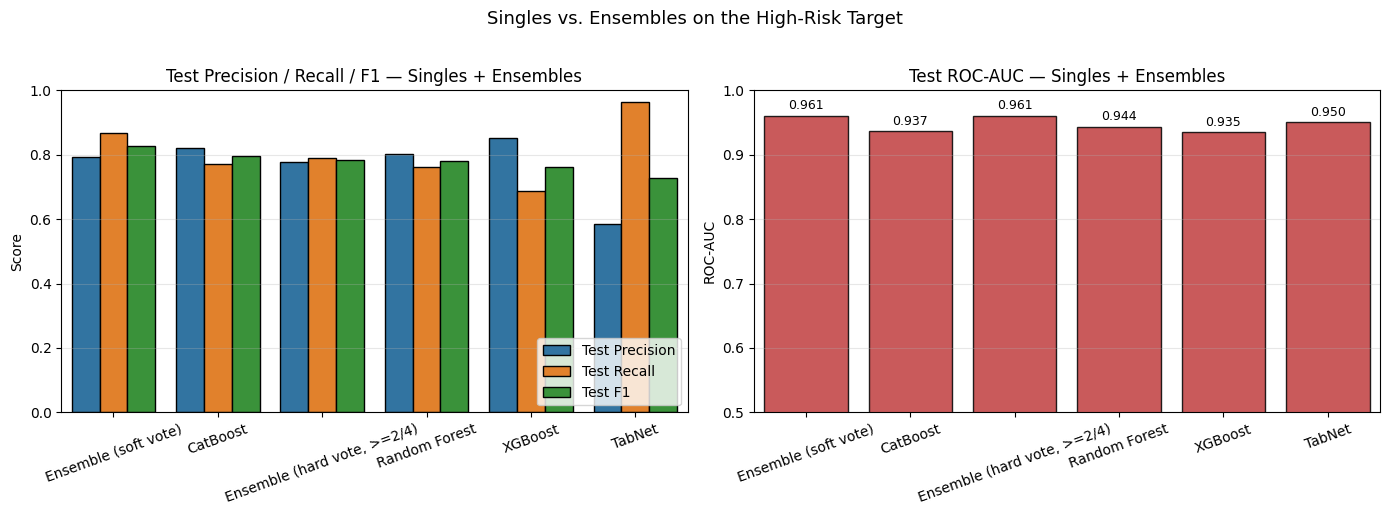

In [20]:
# === Ensemble: soft (probability average) + hard (majority) voting ===
# Reuses the train/test probabilities already produced by each model above.
# CatBoost's probabilities here come from the regularized + val-tuned model.

member_train_probs = np.vstack([rf_train_prob, xgb_train_prob, tabnet_train_prob, cat_train_prob])
member_test_probs  = np.vstack([rf_test_prob,  xgb_test_prob,  tabnet_test_prob,  cat_test_prob])

# 1) SOFT VOTING -----------------------------------------------------------
ens_train_prob = member_train_probs.mean(axis=0)
ens_test_prob  = member_test_probs.mean(axis=0)

ens_threshold, ens_sweep, ens_best = select_threshold(y_train_rf, ens_train_prob)
y_test_pred_soft = (ens_test_prob >= ens_threshold).astype(int)

soft_metrics = {
    "Model":          "Ensemble (soft vote)",
    "Threshold":      ens_threshold,
    "Train Recall":   recall_score(y_train_rf, (ens_train_prob >= ens_threshold).astype(int), zero_division=0),
    "Test Accuracy":  accuracy_score(y_test_rf, y_test_pred_soft),
    "Test Precision": precision_score(y_test_rf, y_test_pred_soft, zero_division=0),
    "Test Recall":    recall_score(y_test_rf, y_test_pred_soft, zero_division=0),
    "Test F1":        f1_score(y_test_rf, y_test_pred_soft, zero_division=0),
    "Test ROC-AUC":   roc_auc_score(y_test_rf, ens_test_prob),
}

# 2) HARD VOTING -----------------------------------------------------------
# Each member uses the threshold it selected during its own evaluation. The
# ensemble flags a row positive when at least 2 of 4 members agree.
def _thr_of(model_name, default=0.50):
    row = next((r for r in results_rows if r["Model"] == model_name), None)
    return float(row["Threshold"]) if row is not None else default

member_test_preds = np.vstack([
    (rf_test_prob     >= _thr_of("Random Forest")).astype(int),
    (xgb_test_prob    >= _thr_of("XGBoost")).astype(int),
    (tabnet_test_prob >= _thr_of("TabNet")).astype(int),
    (cat_test_prob    >= _thr_of("CatBoost")).astype(int),
])
hard_vote_count = member_test_preds.sum(axis=0)
y_test_pred_hard = (hard_vote_count >= 2).astype(int)  # majority of 4

hard_metrics = {
    "Model":          "Ensemble (hard vote, >=2/4)",
    "Threshold":      np.nan,
    "Train Recall":   np.nan,
    "Test Accuracy":  accuracy_score(y_test_rf, y_test_pred_hard),
    "Test Precision": precision_score(y_test_rf, y_test_pred_hard, zero_division=0),
    "Test Recall":    recall_score(y_test_rf, y_test_pred_hard, zero_division=0),
    "Test F1":        f1_score(y_test_rf, y_test_pred_hard, zero_division=0),
    # Hard vote has no native probability; reuse soft probabilities for ROC-AUC reference.
    "Test ROC-AUC":   roc_auc_score(y_test_rf, ens_test_prob),
}

results_rows.extend([soft_metrics, hard_metrics])

ensemble_df = pd.DataFrame(results_rows)[
    ["Model", "Threshold", "Test Accuracy", "Test Precision", "Test Recall", "Test F1", "Test ROC-AUC"]
].copy()
ensemble_df = ensemble_df.sort_values("Test F1", ascending=False).reset_index(drop=True)

print("Final comparison including ensembles (test set, year >= 2024):")
print(ensemble_df.round(3).to_string(index=False))

best_f1_row  = ensemble_df.iloc[0]
best_auc_row = ensemble_df.sort_values("Test ROC-AUC", ascending=False).iloc[0]
print(
    f"\nBest F1:      {best_f1_row['Model']}  "
    f"(F1={best_f1_row['Test F1']:.3f}, Recall={best_f1_row['Test Recall']:.3f}, "
    f"Precision={best_f1_row['Test Precision']:.3f})"
)
print(
    f"Best ROC-AUC: {best_auc_row['Model']}  (ROC-AUC={best_auc_row['Test ROC-AUC']:.3f})"
)

# Visualize singles + ensembles side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

melt_e = ensemble_df.melt(
    id_vars="Model",
    value_vars=["Test Precision", "Test Recall", "Test F1"],
    var_name="Metric", value_name="Score",
)
sns.barplot(data=melt_e, x="Model", y="Score", hue="Metric", ax=axes[0], edgecolor="black")
axes[0].set_title("Test Precision / Recall / F1 — Singles + Ensembles")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(loc="lower right")

sns.barplot(
    data=ensemble_df, x="Model", y="Test ROC-AUC",
    ax=axes[1], color="C3", edgecolor="black", alpha=0.85,
)
for i, v in enumerate(ensemble_df["Test ROC-AUC"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Test ROC-AUC — Singles + Ensembles")
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Singles vs. Ensembles on the High-Risk Target", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Conclusion

## Why the Soft-Vote Ensemble Helps

The soft-vote ensemble is just the **per-row average of `P(high_risk)`** across Random Forest, XGBoost, TabNet, and the regularized CatBoost. Three things make it a meaningful upgrade over any individual model, and the plots below were chosen to make each one visible:

1. **ROC and Precision–Recall curves overlay** — when the soft-vote curve sits on or above the member curves over the operationally relevant range, the ensemble dominates *across thresholds*, not just at the one we picked. This is the cleanest evidence that averaging probabilities is doing real work, since both curves are threshold-free summaries of ranking quality.
2. **Class-conditional probability histograms for the soft vote** — by splitting the ensemble probability on the test set into "true high-risk" vs "true low-risk," we can see whether averaging produces well-separated distributions. A vertical line marks the train-tuned threshold so the operating point is in plain view alongside the underlying density.
3. **Member-probability correlation heatmap** — soft voting only helps when the members are *partially* uncorrelated; if all four models made the same mistakes, averaging would change nothing. Pairwise correlations in the 0.6–0.9 range are the sweet spot: enough agreement to be individually competent, enough disagreement that errors cancel.

Together these plots support the simple narrative: each model is good at slightly different rows, the average **smooths out idiosyncratic mistakes**, and the resulting ranking generalizes better to the 2024–2025 test window than any single member.

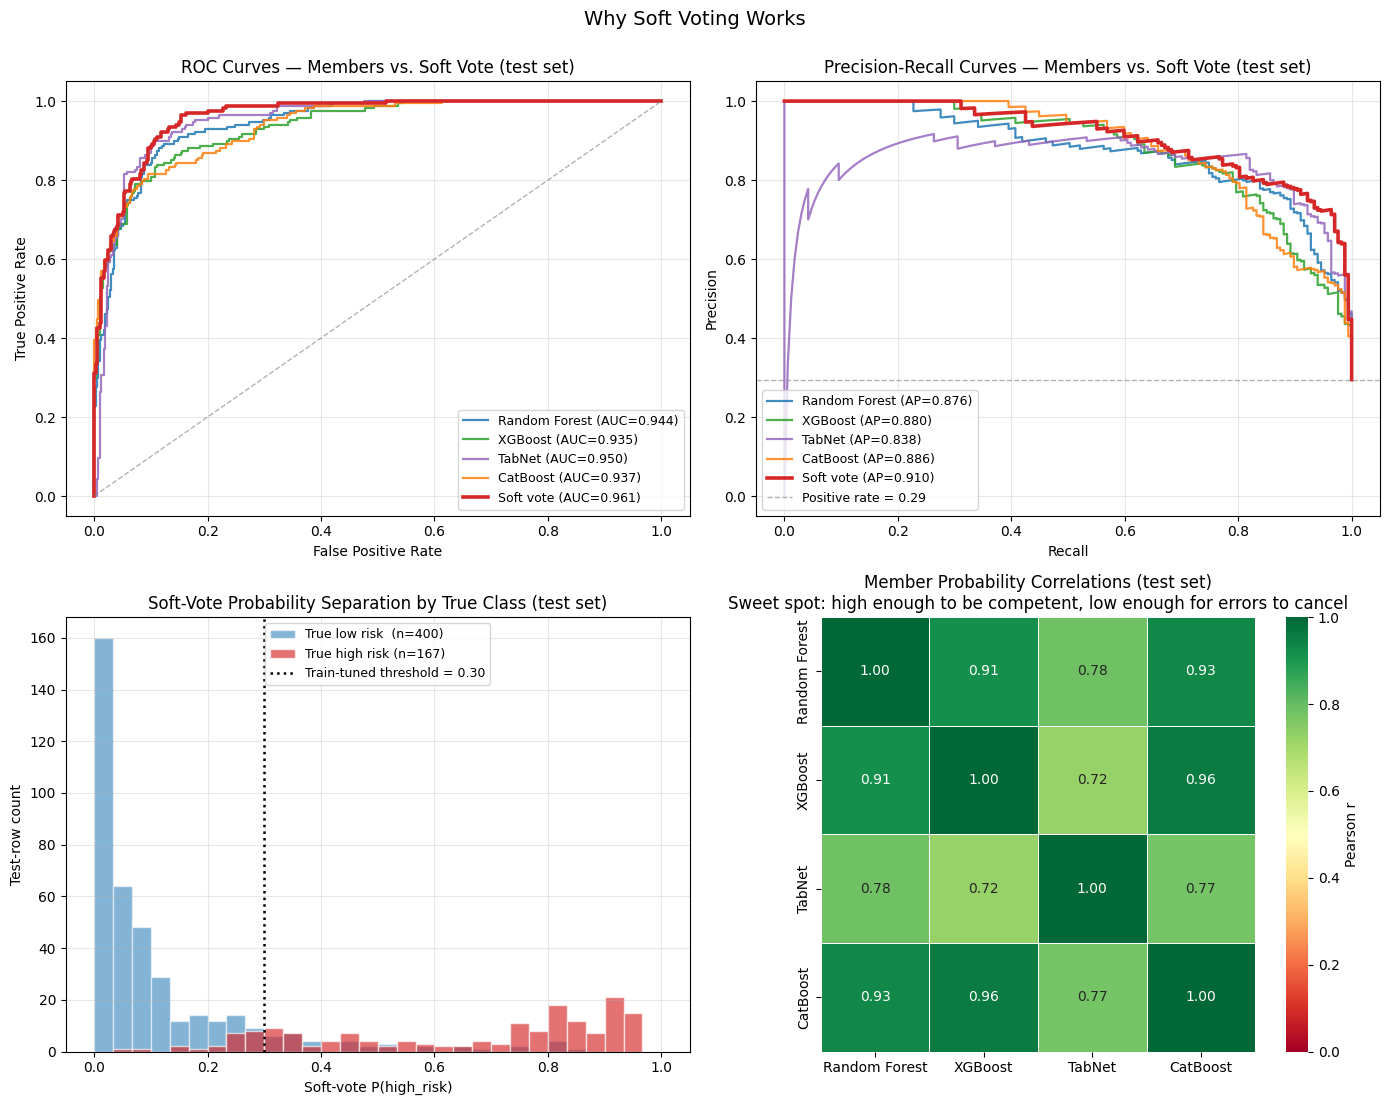


--- Quick read ---
Soft-vote test ROC-AUC:   0.961
Soft-vote test AP (PR-AUC): 0.910
Member ROC-AUCs: Random Forest=0.944, XGBoost=0.935, TabNet=0.950, CatBoost=0.937
Member APs:      Random Forest=0.876, XGBoost=0.880, TabNet=0.838, CatBoost=0.886
Soft-vote test Recall/Precision/F1 at thr=0.30: 0.868 / 0.792 / 0.829


In [21]:
# Conclusion plots: showcase WHY the soft-vote ensemble works.
# Reuses test probabilities + the ensemble already computed above.
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

member_probs = {
    "Random Forest": rf_test_prob,
    "XGBoost":       xgb_test_prob,
    "TabNet":        tabnet_test_prob,
    "CatBoost":      cat_test_prob,
}
ensemble_prob = ens_test_prob  # mean of the four members on the test set

member_colors = {
    "Random Forest": "#1f77b4",
    "XGBoost":       "#2ca02c",
    "TabNet":        "#9467bd",
    "CatBoost":      "#ff7f0e",
}
ensemble_color = "#d62728"

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- (0,0) ROC curves overlay ----------------------------------------------
ax = axes[0, 0]
for name, prob in member_probs.items():
    fpr, tpr, _ = roc_curve(y_test_rf, prob)
    auc = roc_auc_score(y_test_rf, prob)
    ax.plot(fpr, tpr, color=member_colors[name], lw=1.6, alpha=0.85,
            label=f"{name} (AUC={auc:.3f})")
fpr_e, tpr_e, _ = roc_curve(y_test_rf, ensemble_prob)
auc_e = roc_auc_score(y_test_rf, ensemble_prob)
ax.plot(fpr_e, tpr_e, color=ensemble_color, lw=2.6,
        label=f"Soft vote (AUC={auc_e:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, alpha=0.6)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Members vs. Soft Vote (test set)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# --- (0,1) Precision-Recall curves overlay ---------------------------------
ax = axes[0, 1]
for name, prob in member_probs.items():
    prec, rec, _ = precision_recall_curve(y_test_rf, prob)
    ap = average_precision_score(y_test_rf, prob)
    ax.plot(rec, prec, color=member_colors[name], lw=1.6, alpha=0.85,
            label=f"{name} (AP={ap:.3f})")
prec_e, rec_e, _ = precision_recall_curve(y_test_rf, ensemble_prob)
ap_e = average_precision_score(y_test_rf, ensemble_prob)
ax.plot(rec_e, prec_e, color=ensemble_color, lw=2.6,
        label=f"Soft vote (AP={ap_e:.3f})")
baseline = y_test_rf.mean()
ax.axhline(baseline, color="gray", linestyle="--", lw=1, alpha=0.6,
           label=f"Positive rate = {baseline:.2f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Members vs. Soft Vote (test set)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)

# --- (1,0) Class-conditional histogram of soft-vote probabilities ----------
ax = axes[1, 0]
bins = np.linspace(0.0, 1.0, 31)
mask_pos = y_test_rf == 1
mask_neg = y_test_rf == 0
ax.hist(ensemble_prob[mask_neg], bins=bins, color="#1f77b4", alpha=0.55,
        label=f"True low risk  (n={mask_neg.sum()})", edgecolor="white")
ax.hist(ensemble_prob[mask_pos], bins=bins, color=ensemble_color, alpha=0.65,
        label=f"True high risk (n={mask_pos.sum()})", edgecolor="white")
ax.axvline(ens_threshold, color="black", linestyle=":", lw=1.8,
           label=f"Train-tuned threshold = {ens_threshold:.2f}")
ax.set_xlabel("Soft-vote P(high_risk)")
ax.set_ylabel("Test-row count")
ax.set_title("Soft-Vote Probability Separation by True Class (test set)")
ax.legend(loc="upper center", fontsize=9)
ax.grid(True, alpha=0.3)

# --- (1,1) Member probability correlation heatmap --------------------------
ax = axes[1, 1]
member_df = pd.DataFrame(member_probs)
corr = member_df.corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0.0, vmax=1.0,
    cbar_kws={"label": "Pearson r"}, square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Member Probability Correlations (test set)\n"
             "Sweet spot: high enough to be competent, low enough for errors to cancel")

plt.suptitle("Why Soft Voting Works", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("\n--- Quick read ---")
print(f"Soft-vote test ROC-AUC:   {auc_e:.3f}")
print(f"Soft-vote test AP (PR-AUC): {ap_e:.3f}")
print(
    "Member ROC-AUCs: " + ", ".join(
        f"{n}={roc_auc_score(y_test_rf, p):.3f}" for n, p in member_probs.items()
    )
)
print(
    "Member APs:      " + ", ".join(
        f"{n}={average_precision_score(y_test_rf, p):.3f}" for n, p in member_probs.items()
    )
)
print(
    f"Soft-vote test Recall/Precision/F1 at thr={ens_threshold:.2f}: "
    f"{soft_metrics['Test Recall']:.3f} / {soft_metrics['Test Precision']:.3f} / "
    f"{soft_metrics['Test F1']:.3f}"
)